In [1]:
pip install wget

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install opencv-python

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np

import matplotlib.pyplot as plt
import os
import cv2
import wget
import zipfile

In [5]:
wget.download("https://drive.google.com/uc?export=download&id=1IMCE-y6zrE8j4ZE-JwlElN5bhQ8xf_Kf", "dataset.zip")

'dataset (4).zip'

In [6]:
zip_path = "dataset.zip"
extract_to = "./"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
  zip_ref.extractall(extract_to)

print("Selesai extract ke:", extract_to)

Selesai extract ke: ./


In [7]:
def load_image(image_path):
  image = cv2.imread(image_path)
  if image is None:
    print('Error: Could not load image.')
    return None, None
  Gray = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
  image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
  return image, Gray

In [8]:
pip install scikit-image

Note: you may need to restart the kernel to use updated packages.


In [9]:
from skimage.feature import hog

# HOG / image params
ORIENTATIONS = 9
PIXELS_PER_CELL = (8, 8)
CELLS_PER_BLOCK = (2, 2)

def extract_hog_features(image_gray):
  features, hog_image = hog(
      image_gray,
      orientations=ORIENTATIONS,
      pixels_per_cell=PIXELS_PER_CELL,
      cells_per_block=CELLS_PER_BLOCK,
      block_norm='L2-Hys',
      visualize=True,
      feature_vector=True
  )
  return features, hog_image

# Ganti ke LBP

In [10]:
def crop_half_image(img, bottom=True):
  h = img.shape[0]
  mid = h // 2
  if bottom:
    cropped = img[mid:, :]
  else:
    cropped = img[:mid, :]
  return cropped

In [11]:
dataset_dir = 'dataset/'
IMAGE_SIZE = (64,64)
X = []
y = []
hog_img =[]
for root, dirs, files in os.walk(dataset_dir):
  print(root, dirs, files)
  for f in files:
    _, image_gray = load_image(os.path.join(root, f))
    img_crop = crop_half_image(image_gray, bottom=True)
    # jika crop menghasilkan area kosong atau sangat kecil, fallback ke citra penuh
    if img_crop is None or img_crop.size == 0 or img_crop.shape[0] < 4 or img_crop.shape[1] < 4:
      img_crop = image_gray # fallback
      # optional: print warning
      print(f"[WARN] Crop menghasilkan area kecil untuk {files}, menggunakan citra penuh.")
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    hog_feature, hog_maps = extract_hog_features(roi_resized)
    if hog_feature is None:
      continue
    hog_img.append(hog_maps)
    X.append(hog_feature)
    if root.split('/')[-1]=="without_mask":
      y.append(0)
    else:
      y.append(1)
# Move array conversion outside the loop
X = np.array(X)
y = np.array(y)
print(f"[INFO] Total sampel fitur: {X.shape[0]}, dimensi fitur: {X.shape[1]}")

dataset/ ['without_mask', 'with_mask'] []
dataset/without_mask [] ['0_0_aidai_0014.jpg', '0_0_aidai_0029.jpg', '0_0_aidai_0043.jpg', '0_0_aidai_0074.jpg', '0_0_aidai_0084.jpg', '0_0_aidai_0136.jpg', '0_0_anhu_0004.jpg', '0_0_anhu_0020.jpg', '0_0_anhu_0025.jpg', '0_0_anhu_0027.jpg', '0_0_anhu_0056.jpg', '0_0_anhu_0057.jpg', '0_0_anhu_0062.jpg', '0_0_anhu_0063.jpg', '0_0_anhu_0098.jpg', '0_0_anhu_0103.jpg', '0_0_anhu_0155.jpg', '0_0_anhu_0157.jpg', '0_0_anhu_0189.jpg', '0_0_anhu_0201.jpg', '0_0_anhu_0205.jpg', '0_0_anhu_0209.jpg', '0_0_anhu_0211.jpg', '0_0_anhu_0214.jpg', '0_0_anhu_0216.jpg', '0_0_baibaihe_0077.jpg', '0_0_baibaihe_0085.jpg', '0_0_baibaihe_0093.jpg', '0_0_baibaihe_0204.jpg', '0_0_baibaihe_0216.jpg', '0_0_baibaihe_0236.jpg', '0_0_baobeier_0014.jpg', '0_0_baobeier_0016.jpg', '0_0_baobeier_0020.jpg', '0_0_baobeier_0046.jpg', '0_0_baobeier_0062.jpg', '0_0_baobeier_0064.jpg', '0_0_baobeier_0098.jpg', '0_0_baobeier_0099.jpg', '0_0_baobeier_0140.jpg', '0_0_benxi_0054.jpg', '0_0_

In [12]:
pip install -U scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [13]:
from sklearn.model_selection import train_test_split

TEST_SIZE = 0.2
RANDOM_STATE = 42

X_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y )

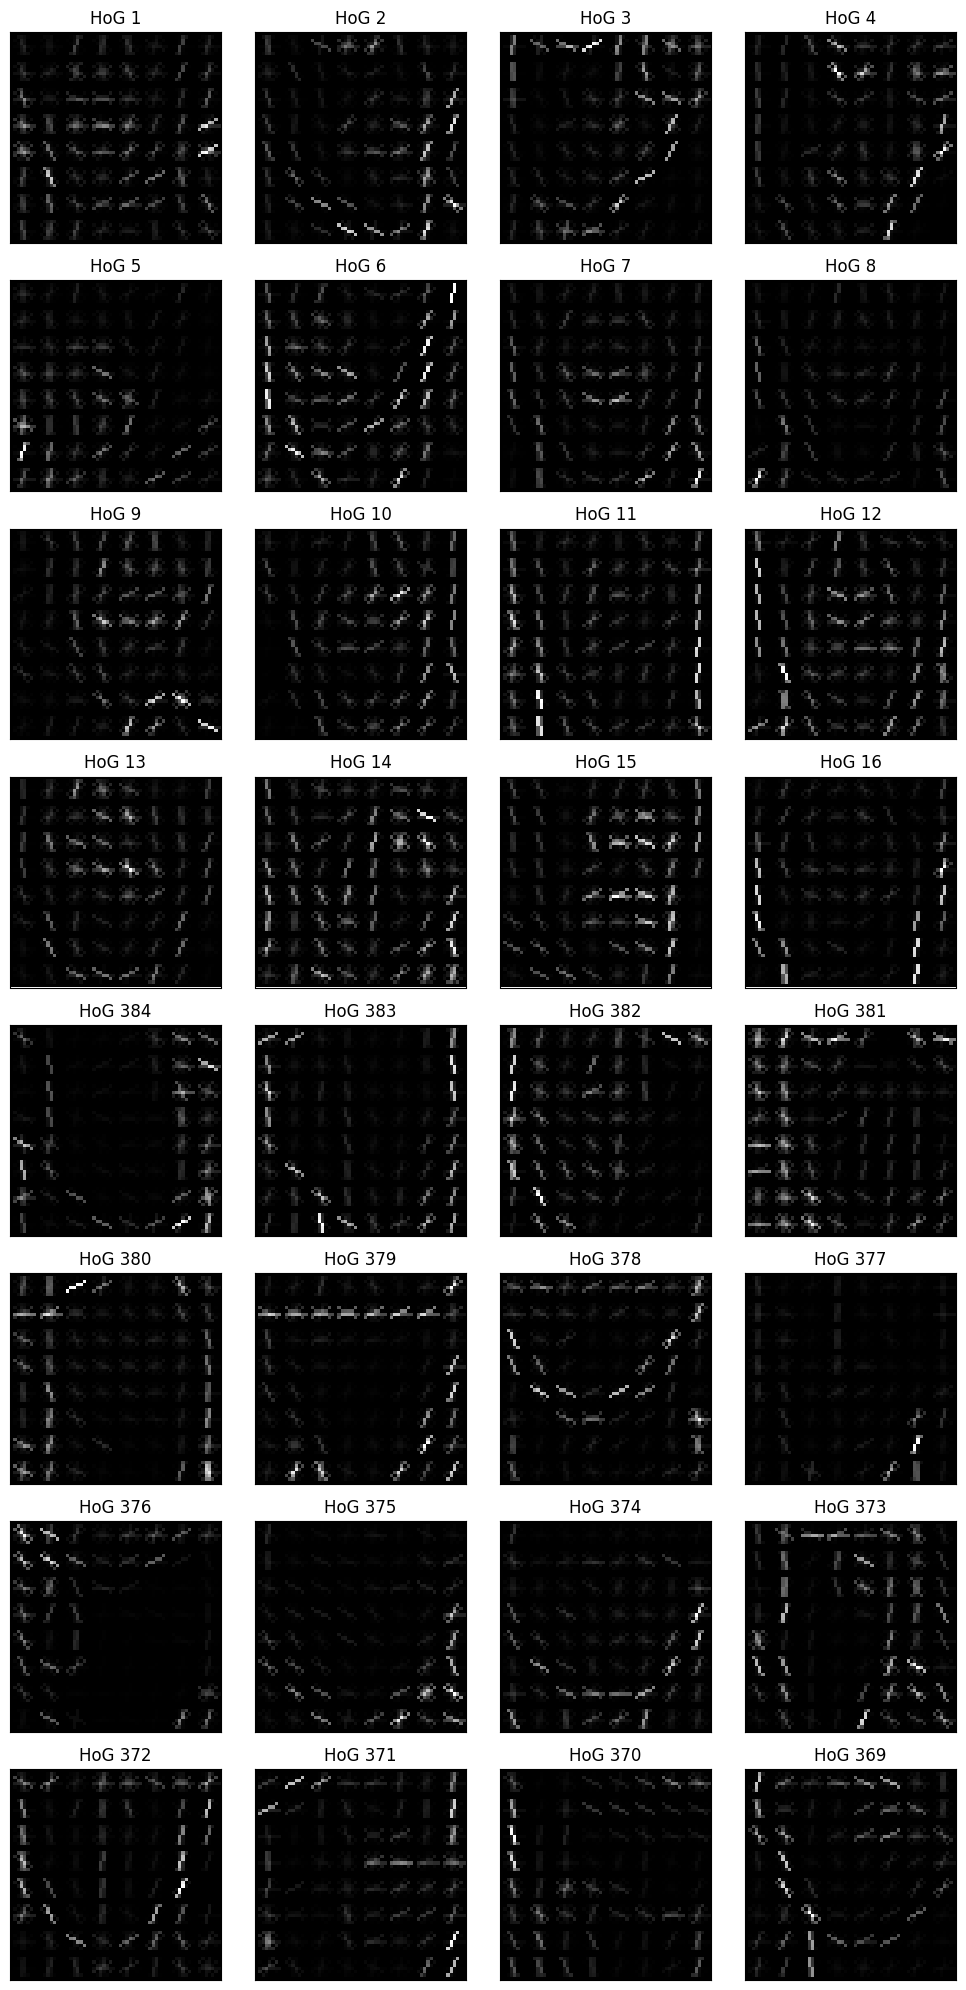

In [14]:
from skimage import exposure

ncol = 4
nrow = 8
fig, axes = plt.subplots(nrow, ncol, figsize=(10, 2.5*nrow),subplot_kw={'xticks':[], 'yticks':[]})
for i, ax in enumerate(axes.flat):
  if i < 16:
    temp =hog_img[i]
    hog_image = exposure.rescale_intensity(temp, in_range=(0, temp.max()))
    ax.imshow(hog_image, cmap='gray')
    ax.set_title(f'HoG {i+1}')
  else:
    temp =hog_img[len(hog_img) - (i)]
    hog_image = exposure.rescale_intensity(temp, in_range=(0, temp.max()))
    ax.imshow(hog_image, cmap='gray')
    ax.set_title(f'HoG {len(hog_img) - (i)}')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix

# scale fitur
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(x_test)

# training SVM (RBF)
clf = SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE)
print("[INFO] Training SVM...")
clf.fit(X_train_s, y_train)

[INFO] Training SVM...


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [16]:
# evaluasi
y_pred = clf.predict(X_test_s)
print("\n[RESULT] Classification report:")
print(classification_report(y_test, y_pred, target_names=["without_mask","with_mask"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


[RESULT] Classification report:
              precision    recall  f1-score   support

without_mask       0.95      0.95      0.95        40
   with_mask       0.95      0.95      0.95        40

    accuracy                           0.95        80
   macro avg       0.95      0.95      0.95        80
weighted avg       0.95      0.95      0.95        80

Confusion Matrix:
[[38  2]
 [ 2 38]]


In [17]:
import joblib
MODEL_PATH = "svm_mas_200_bottom_half.pkl"
# simpan model + scaler
joblib.dump({"model": clf,
             "scaler": scaler,
             "config": {"image_size" : IMAGE_SIZE,
                        "hog_params": {"orientations": ORIENTATIONS,
                                       "pixels_per_cell": PIXELS_PER_CELL,
                                       "cells_per_block": CELLS_PER_BLOCK},
                                       "crop": "bottom"}}, MODEL_PATH)
print(f"[INFO] Model tersimpan di: {MODEL_PATH}")

[INFO] Model tersimpan di: svm_mas_200_bottom_half.pkl


In [18]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

In [19]:
def detect_faces(image_gray, scale_factor=1.1, min_neighbors=5, min_size=(30, 30)):
  faces = face_cascade.detectMultiScale(
      image_gray,
      scaleFactor=scale_factor,
      minNeighbors=min_neighbors,
      minSize=min_size
  )
  return faces

In [20]:
def crop_faces(image_gray, faces, return_all=False):
  cropped_faces = []
  selected_faces = []
  if len(faces) > 0:
    if return_all:
      for x, y, w, h in faces:
        selected_faces.append((x, y, w, h))
        cropped_faces.append(image_gray[y:y+h, x:x+w])
    else:
      x, y, w, h = max(faces, key=lambda rect: rect[2] * rect[3])
      selected_faces.append((x, y, w, h))
      cropped_faces.append(image_gray[y:y+h, x:x+w])
  return cropped_faces, selected_faces

In [21]:
def feature_extraction_for_test(image_gray):
  features, hog_maps = [],[]
  faces = detect_faces(image_gray)
  cropped_face, _ = crop_faces(image_gray, faces)
  if cropped_face is None:
    print("wajah tidak terdeteksi..")
    return features, hog_maps
  else:
    img_crop = crop_half_image(cropped_face[0], bottom=True)
    # jika crop menghasilkan area kosong atau sangat kecil, fallback ke citra penuh
    if img_crop is None or img_crop.size == 0 or img_crop.shape[0]<4 or img_crop.shape[1]<4:
      img_crop = cropped_face[0] # fallback
      # optional: print warning
      print(f"[WARN] Crop menghasilkan area kecil untuk {files}, menggunakan citra penuh.")
    roi_resized = cv2.resize(img_crop, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    features, hog_maps = extract_hog_features(roi_resized)
    features = np.array(features)
    features = features.reshape(1, -1)
    return features, hog_maps

In [22]:
import joblib
def predict_image(image, features, model_path):
  data = joblib.load(model_path)
  model_loaded = data.get("model")
  scaler = data.get("scaler")
  if scaler is not None:
    features = scaler.transform(features)
    pred = model_loaded.predict(features)[0]
    conf = None
    prob = 0
    prob = model_loaded.predict_proba(features)[0] if hasattr(model_loaded, "predict_proba") else None
    conf = float(max(prob))
    if pred == 1:
      label_str = "MASK"
    else:
      label_str = "NO MASK"
    print(f"Prediksi: {label_str}")
    return draw_result(image, conf, label_str)

In [23]:
def draw_text(image, label, score,
              font=cv2.FONT_HERSHEY_SIMPLEX,
              pos=(10, 30),
              font_scale=0.6,
              font_thickness=2,
              text_color=(255, 255, 255),
              text_color_bg=(0, 0, 255)
              ):
  x, y = pos
  score_text = f'Score: {score:.2f}'

  (w1, h1), _ = cv2.getTextSize(score_text, font, font_scale, font_thickness)
  (w2, h2), _ = cv2.getTextSize(label, font, font_scale, font_thickness)

  box_width = max(w1, w2) + 20
  box_height = h1 + h2 + 25

  # pastikan tidak keluar dari gambar (opsional)
  x = max(0, x)
  y = max(box_height, y)

  # background kotak
  cv2.rectangle(image,
   (x, y - box_height),
    (x + box_width, y),
                text_color_bg,
                -1)

  # tulis label
  cv2.putText(image, label, (x + 10, y - h1 - 10),
              font, font_scale, text_color, font_thickness)

  # tulis score
  cv2.putText(image, score_text, (x + 10, y - 10),
              font, font_scale, text_color, font_thickness)

def draw_result(image_bgr, score, label):
    result_image = image_bgr.copy()
    draw_text(result_image, label, score, pos=(10, 40))
    return result_image

Prediksi: MASK


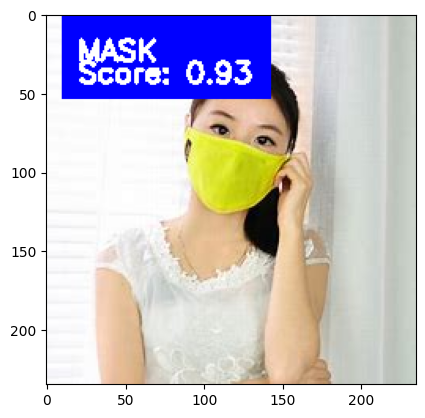

In [24]:
TESTING_IMAGE = "testing/mask1.png"
hog_feature, hog_maps = [],[]
image_rgb, image_gray = load_image(TESTING_IMAGE)
hog_feature, hog_maps = feature_extraction_for_test(image_gray)
result_image = predict_image(image_rgb, hog_feature, MODEL_PATH)
plt.imshow(result_image)

In [25]:
import cv2
import joblib
from skimage.feature import hog

# ------- KONFIG -------
FACE_CASCADE = "haarcascade_frontalface_default.xml"
NOSE_CASCADE = "haarcascade_mcs_nose.xml"
MODEL_FILE = "svm_mask_200_bottom_half.pkl"
VIDEO_SRC = 0

IMAGE_SIZE = (64, 64)
HOG_PARAMS = dict(orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2),
                  block_norm='L2-Hys', visualize=False, feature_vector=True)

In [26]:
data = joblib.load(MODEL_FILE)
model = data.get("model")
scaler = data.get("scaler")

face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + FACE_CASCADE)
nose_cascade = cv2.CascadeClassifier(NOSE_CASCADE)

C:\Users\Mikail Achmad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator SVC from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Mikail Achmad\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.5.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [27]:
def extract_hog(img):
  return hog(img, **HOG_PARAMS).reshape(1, -1)

def predict_from_roi(roi_gray):
  roi = cv2.resize(roi_gray, IMAGE_SIZE, interpolation=cv2.INTER_AREA)
  feat = extract_hog(roi)
  if scaler is not None:
    feat = scaler.transform(feat)
  pred = model.predict(feat)[0]
  conf = None
  if hasattr(model, "predict_proba"):
    conf = float(max(model.predict_proba(feat)[0]))
  return pred, conf

In [28]:
cap = cv2.VideoCapture(VIDEO_SRC)

In [29]:
while True:
  ret, frame = cap.read()
  if not ret:
    break

  if frame.shape[1] > 1280:
    scale = 1280 / frame.shape[1]
    frame = cv2.resize(frame, None, fx=scale, fy=scale, interpolation=cv2.INTER_AREA)

  gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
  faces = face_cascade.detectMultiScale(gray, 1.1, 5, minSize=(60,60))

  for (x,y,w,h) in faces:
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = frame[y:y+h, x:x+w]

    ny1 = int(h * 0.35); ny2 = int(h * 0.90)
    roi_nose = roi_gray[ny1:ny2, :]

    noses = nose_cascade.detectMultiScale(roi_nose, scaleFactor=1.1, minNeighbors=4, minSize=(20,20))

    half = h // 2
    roi_bottom = roi_gray[half:h, :]
    use_roi = roi_bottom if roi_bottom.size >= 64 else (roi_nose if roi_nose.size >= 64 else roi_gray)

    if len(noses) > 0:
      label = "NO MASK"
      color = (0,0,255)
      for (nx, ny, nw, nh) in noses:
        cv2.rectangle(roi_color, (nx, ny+ny1), (nx+nw, ny+ny1+nh), color, 1)
      else:
        pred, conf = predict_from_roi(use_roi)
        if pred == 1:
          label, color = "MASK", (0,255,0)
        else:
          label, color = "NO MASK", (0,0,255)
        if conf is not None:
          cv2.putTest(frame, f"{conf:.2f}", (x, y+h+18), cv2.FONT_HERSHY_SIMPLWX, 0.6, color, 2)